In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('data/real_estate_clean_v1.csv',encoding='cp949')

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_14108/4271754184.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv',encoding='cp949')


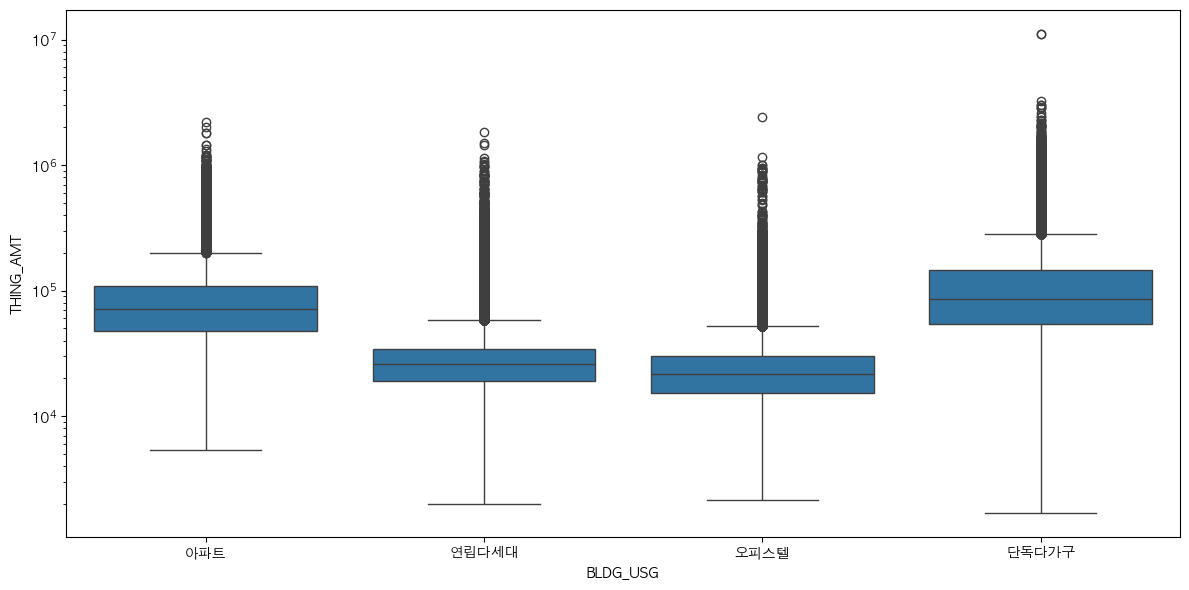

In [51]:
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='BLDG_USG', y='THING_AMT')
plt.yscale('log') # 범위가 너무 넓어서 로그스케일 사용
plt.tight_layout() 
plt.show()

## 아파트 이상치 확인

<class 'pandas.core.frame.DataFrame'>
Index: 375767 entries, 0 to 794605
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  375767 non-null  int64  
 1   CGG_CD      375767 non-null  int64  
 2   CGG_NM      375767 non-null  object 
 3   STDG_CD     375767 non-null  int64  
 4   STDG_NM     375767 non-null  object 
 5   BLDG_NM     375767 non-null  object 
 6   CTRT_DAY    375767 non-null  object 
 7   THING_AMT   375767 non-null  int64  
 8   ARCH_AREA   375767 non-null  float64
 9   LAND_AREA   214827 non-null  float64
 10  FLR         375767 non-null  float64
 11  RGHT_SE     7039 non-null    object 
 12  ARCH_YR     375767 non-null  int64  
 13  BLDG_USG    375767 non-null  object 
 14  DCLR_SE     92761 non-null   object 
 15  CTRT_YEAR   375767 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 48.7+ MB


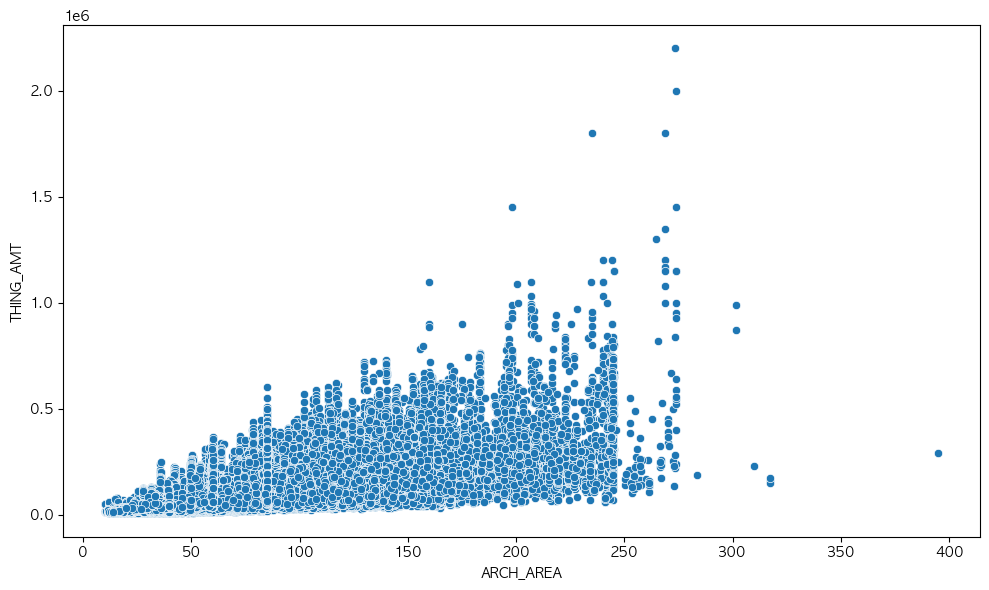

In [52]:
# 아파트
apt = df[df['BLDG_USG']=='아파트']
apt.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

In [86]:
apt['ARCH_AREA'].describe()

count    375767.000000
mean         76.420447
std          30.520939
min          10.020000
25%          59.650000
50%          81.050000
75%          84.960000
max         395.060000
Name: ARCH_AREA, dtype: float64

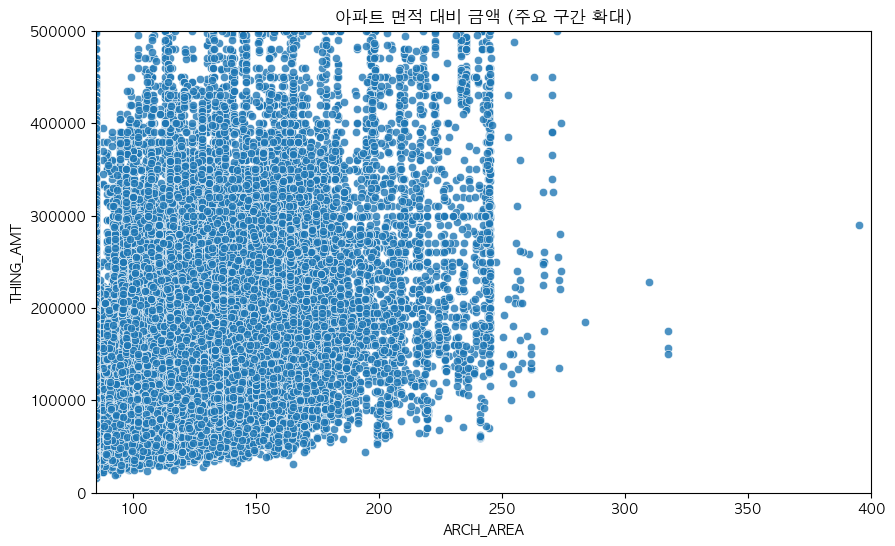

In [55]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

area_q3 = apt['ARCH_AREA'].quantile(0.75)
# x축: q3 ~ 400 (건물면적 최댓값이 395)
# y축: 금액 50억(500,000만원) 이하로 제한
plt.xlim(area_q3,400)
plt.ylim(0, 0.5e+06)

plt.title('아파트 면적 대비 금액 (주요 구간 확대)')
plt.show()

In [56]:
apt[apt['ARCH_AREA']>300]

,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
8974,8974,11170,용산구,12900,이촌동,정우,2018-10-26,157000,317.36,NaN,5.0,NaN,1972,아파트,NaN,2018
17365,17365,11650,서초구,10800,서초동,월드빌라트,2018-09-28,290000,395.06,NaN,10.0,NaN,1996,아파트,NaN,2018
356007,373613,11170,용산구,12900,이촌동,정우,2020-07-04,150000,317.36,0.0,2.0,NaN,1972,아파트,NaN,2020
531853,556901,11170,용산구,12900,이촌동,정우,2021-05-13,175000,317.36,0.0,9.0,NaN,1972,아파트,NaN,2021
623827,654248,11680,강남구,11800,도곡동,타워팰리스1,2022-05-12,870000,301.47,0.0,56.0,NaN,2002,아파트,중개거래,2022
679683,713369,11680,강남구,11800,도곡동,타워팰리스1,2023-07-31,990000,301.47,0.0,55.0,NaN,2002,아파트,중개거래,2023
708086,743250,11140,중구,14300,장충동1가,장충레지던스,2023-03-16,228000,309.70,0.0,4.0,NaN,1993,아파트,직거래,2023


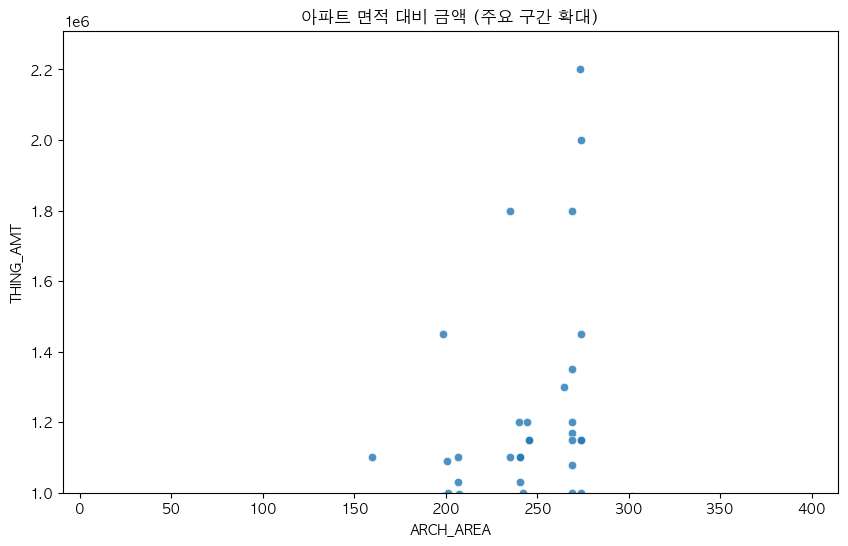

In [57]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

# y축: 금액 100억(1,000,000만원) 이상
# plt.xlim(area_q3,400)
plt.ylim(1.0e+06,)

plt.title('아파트 면적 대비 금액 (주요 구간 확대)')
plt.show()

In [58]:
# 가격이 높게 형성된 매물 확인
high_price = apt.loc[apt['THING_AMT']>=1.0e+06,['CTRT_YEAR','STDG_NM','BLDG_NM','THING_AMT','ARCH_AREA','FLR','DCLR_SE']]
high_price

,CTRT_YEAR,STDG_NM,BLDG_NM,THING_AMT,ARCH_AREA,FLR,DCLR_SE
461762,2021,한남동,파르크한남,1200000,268.950,2.0,직거래
464987,2021,한남동,파르크한남,1170000,268.670,4.0,직거래
465689,2021,한남동,파르크한남,1150000,268.950,3.0,직거래
485513,2021,한남동,파르크한남,1080000,268.670,2.0,NaN
498770,2021,한남동,파르크한남,1000000,268.670,3.0,NaN
508949,2021,청담동,PH129,1000000,273.960,6.0,NaN
559369,2021,청담동,PH129,1150000,273.960,14.0,NaN
559373,2021,청담동,PH129,1150000,273.960,14.0,NaN
600073,2022,성수동1가,아크로서울포레스트,1300000,264.550,47.0,중개거래
619078,2022,한남동,한남더힐,1100000,240.310,3.0,중개거래


In [59]:
'''
- 청담동 PH129 100평 100억 이상대(2021년부터) + 직거래의 경우 100억 이하로도 거래내역 확인 가능 

- 성수동1가 갤러리아포레 99평 2023년부터 100억 이상 확인
- 한남동 나인원한남 89평 2024년부터 100억이상 확인
    주택
- 반포동 아크로리버파크 71평 2025년 기준 95억 -> 95평의 경우 2023-2024년 기준 100억 이상 가능
- 성수동1가 아크로서울포레스트 75평 2024년부터 100억이상 확인,
- 한남동 파르크한남 96평 기준 2021년부터 100억 이상 확인
'''

'\n- 청담동 PH129 100평 100억 이상대(2021년부터) + 직거래의 경우 100억 이하로도 거래내역 확인 가능 \n\n- 성수동1가 갤러리아포레 99평 2023년부터 100억 이상 확인\n- 한남동 나인원한남 89평 2024년부터 100억이상 확인\n    주택\n- 반포동 아크로리버파크 71평 2025년 기준 95억 -> 95평의 경우 2023-2024년 기준 100억 이상 가능\n- 성수동1가 아크로서울포레스트 75평 2024년부터 100억이상 확인,\n- 한남동 파르크한남 96평 기준 2021년부터 100억 이상 확인\n'

## 연립다세대

In [60]:
# 연립다세대 데이터만 추출
yeon = df.loc[df['BLDG_USG']=='연립다세대'].copy() 

<class 'pandas.core.frame.DataFrame'>
Index: 279723 entries, 3 to 794603
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  279723 non-null  int64  
 1   CGG_CD      279723 non-null  int64  
 2   CGG_NM      279723 non-null  object 
 3   STDG_CD     279723 non-null  int64  
 4   STDG_NM     279723 non-null  object 
 5   BLDG_NM     279722 non-null  object 
 6   CTRT_DAY    279723 non-null  object 
 7   THING_AMT   279723 non-null  int64  
 8   ARCH_AREA   279723 non-null  float64
 9   LAND_AREA   279723 non-null  float64
 10  FLR         279723 non-null  float64
 11  RGHT_SE     0 non-null       object 
 12  ARCH_YR     279723 non-null  int64  
 13  BLDG_USG    279723 non-null  object 
 14  DCLR_SE     78082 non-null   object 
 15  CTRT_YEAR   279723 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 36.3+ MB


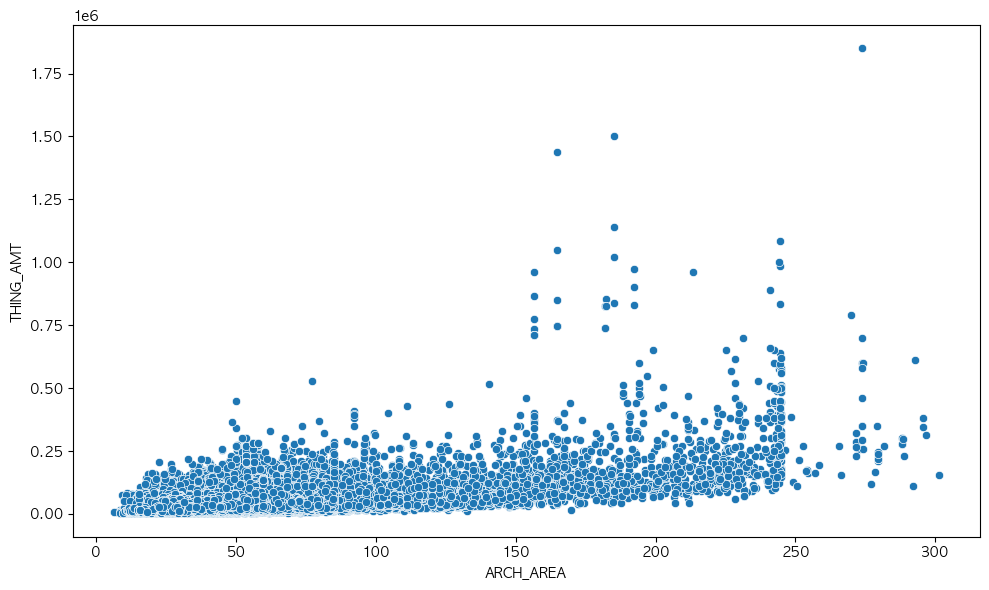

In [61]:
# 연립다세대
yeon = df[df['BLDG_USG']=='연립다세대']
yeon.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=yeon, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

In [62]:
yeon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279723 entries, 3 to 794603
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  279723 non-null  int64  
 1   CGG_CD      279723 non-null  int64  
 2   CGG_NM      279723 non-null  object 
 3   STDG_CD     279723 non-null  int64  
 4   STDG_NM     279723 non-null  object 
 5   BLDG_NM     279722 non-null  object 
 6   CTRT_DAY    279723 non-null  object 
 7   THING_AMT   279723 non-null  int64  
 8   ARCH_AREA   279723 non-null  float64
 9   LAND_AREA   279723 non-null  float64
 10  FLR         279723 non-null  float64
 11  RGHT_SE     0 non-null       object 
 12  ARCH_YR     279723 non-null  int64  
 13  BLDG_USG    279723 non-null  object 
 14  DCLR_SE     78082 non-null   object 
 15  CTRT_YEAR   279723 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 36.3+ MB


In [63]:
yeon['FLR'].value_counts()

FLR
 2.0     70213
 3.0     61743
 4.0     48671
 1.0     33038
 5.0     31132
-1.0     20106
 6.0      9794
 7.0      1940
 8.0      1123
 9.0       703
 10.0      457
 11.0      295
 12.0      188
 13.0      120
 14.0       60
 15.0       36
 16.0       34
-2.0        26
 18.0       15
 17.0       13
 19.0        9
 20.0        6
-3.0         1
Name: count, dtype: int64

In [64]:
ten_yeon = yeon[yeon['FLR']==10]

In [65]:
# 7층 연립다세대 데이터 추출
seven_yeon = yeon[yeon['FLR']==7]

# 8층 연립다세대 데이터 추출
eight_yeon = yeon[yeon['FLR']==8]

In [66]:
seven_yeon[['CGG_NM','STDG_NM','BLDG_NM','CTRT_DAY','THING_AMT','ARCH_AREA','LAND_AREA','ARCH_YR']]

,CGG_NM,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,ARCH_YR
436,강서구,방화동,불루힐,2018-12-22,18800,27.38,14.50,2015
2145,마포구,동교동,더라움,2018-12-04,44000,36.15,16.70,2018
2343,중랑구,상봉동,청운명가,2018-12-03,22500,29.85,16.60,2017
2584,마포구,동교동,더라움,2018-12-01,42800,39.49,18.25,2018
3348,강서구,가양동,(184-5),2018-11-26,26500,27.68,12.59,2017
...,...,...,...,...,...,...,...,...
793569,은평구,불광동,해피하우스(281-16),2023-12-26,20000,19.77,7.16,2017
794038,강서구,등촌동,에스엠파크빌,2023-12-19,26000,24.64,15.01,2017
794177,금천구,시흥동,은연빌라트A,2023-12-16,33500,43.55,17.67,2016
794498,강서구,화곡동,에벤에셀,2023-12-05,48000,69.60,26.31,2009


In [67]:
eight_yeon[['CGG_NM','STDG_NM','BLDG_NM','CTRT_DAY','THING_AMT','ARCH_AREA','LAND_AREA','ARCH_YR']]

,CGG_NM,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,ARCH_YR
539,양천구,목동,목동토레스타워,2018-12-21,37800,34.91,16.79,2018
1214,강동구,천호동,다성이즈빌(169-6),2018-12-14,22000,19.14,6.61,2018
1837,중랑구,상봉동,포시즌빌,2018-12-07,21700,26.69,13.77,2016
3708,중랑구,면목동,스마트빌,2018-11-22,29000,50.35,19.42,2016
4255,동작구,사당동,사당휴브리지(206-127),2018-11-19,16700,12.42,8.27,2015
...,...,...,...,...,...,...,...,...
791224,영등포구,문래동1가,2030센터뷰,2024-01-12,40000,26.78,11.51,2023
791268,동작구,대방동,대방주상복합빌딩,2024-01-12,25900,24.31,6.14,2016
791460,강동구,천호동,美笑家,2024-01-11,37000,24.45,7.98,2023
791631,강동구,천호동,美笑家,2024-01-10,34000,25.23,8.24,2023


- 7층 8층의 경우 다세대주택과 오피스텔의 경계지점일 것으로 유추되어 집중조사해봄
- 그 결과, 건물용도의 경우 사용 비율에 따라 구분하고, 비율이 높은 용도를 표기한 것으로 유추됨.
- 따라서 보통 7층까지는 다세대주택 용도로 사용되는 것이 대부분이고, 
- 8층부터는 오피스텔과 다세대주택이 둘다 나타날 수 있는 경계선이라고 보임
- --> 너무 성급한 일반화? or too much detail?

## 오피스텔

In [68]:
df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_14108/2608460116.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


<class 'pandas.core.frame.DataFrame'>
Index: 86005 entries, 7 to 794602
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  86005 non-null  int64  
 1   CGG_CD      86005 non-null  int64  
 2   CGG_NM      86005 non-null  object 
 3   STDG_CD     86005 non-null  int64  
 4   STDG_NM     86005 non-null  object 
 5   BLDG_NM     85943 non-null  object 
 6   CTRT_DAY    86005 non-null  object 
 7   THING_AMT   86005 non-null  int64  
 8   ARCH_AREA   86005 non-null  float64
 9   LAND_AREA   86005 non-null  float64
 10  FLR         86005 non-null  float64
 11  RGHT_SE     0 non-null      object 
 12  ARCH_YR     86005 non-null  int64  
 13  BLDG_USG    86005 non-null  object 
 14  DCLR_SE     33171 non-null  object 
 15  CTRT_YEAR   86005 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 11.2+ MB


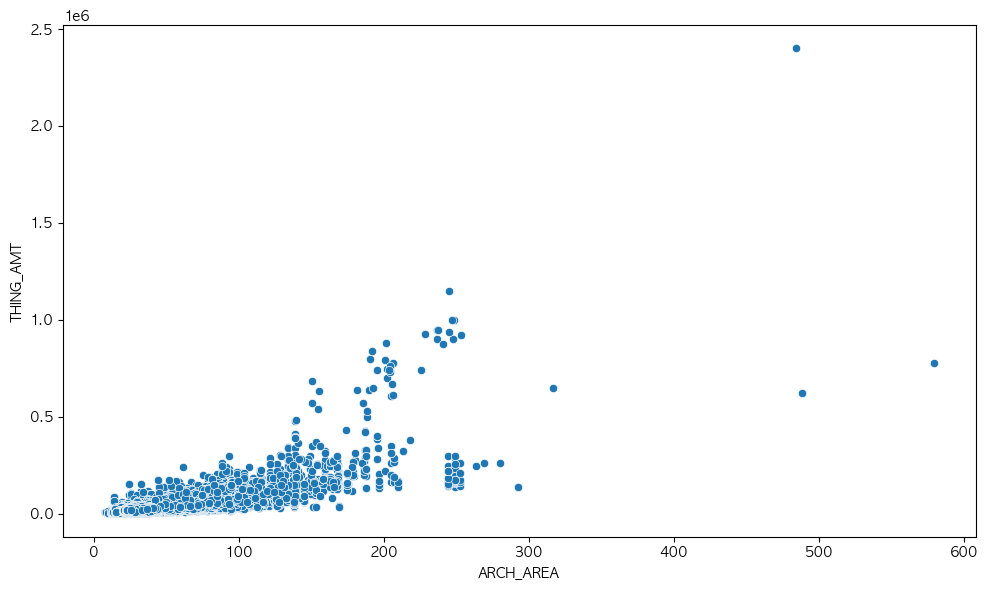

In [ ]:
# 오피스텔
office = df[df['BLDG_USG']=='오피스텔']
office.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=office, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

In [70]:
weird_office = office.loc[office['ARCH_AREA']>300,['STDG_NM','BLDG_NM','CTRT_DAY','THING_AMT','ARCH_AREA','FLR']]
weird_office

,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,FLR
263283,청담동,피엔폴루스,2019-03-27,650000,316.88,22.0
331593,동자동,트윈시티 남산,2020-08-19,621860,488.54,2.0
605591,한강로2가,용산 토투벨리,2022-08-16,780000,579.27,14.0
657965,신천동,롯데월드타워앤드롯데월드몰,2023-11-23,2400000,483.96,68.0


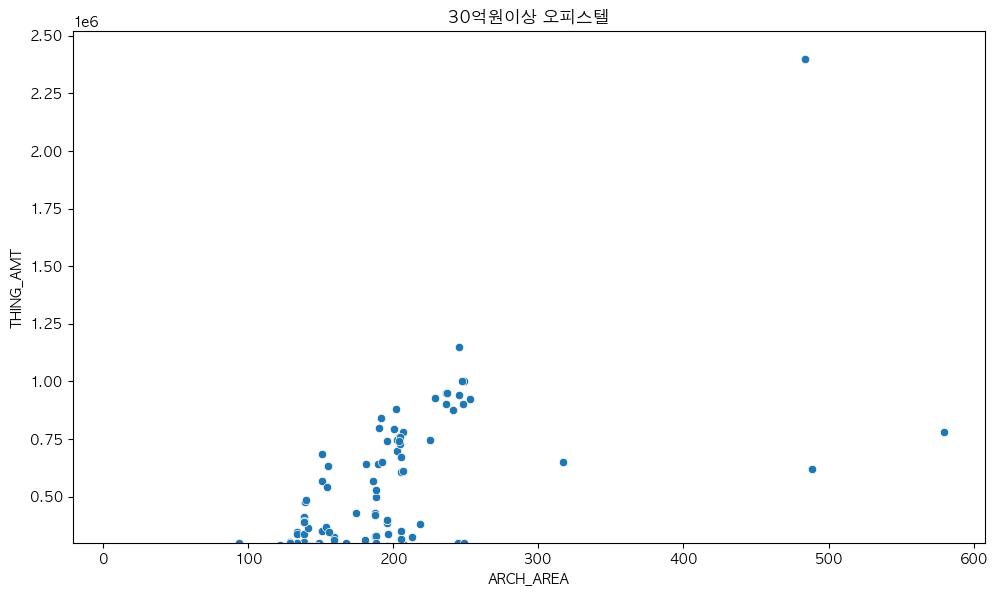

In [71]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=office, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.ylim(0.3e+06,)
plt.title('30억원이상 오피스텔')
plt.show()

In [72]:
office[office['THING_AMT']>0.3e+06]

,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
59375,59377,11680,강남구,10400,청담동,피엔폴루스,2018-07-20,385000,195.43,267.79,17.0,NaN,2007,오피스텔,NaN,2018
170884,184246,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2019-11-08,498060,188.04,310.55,48.0,NaN,9999,오피스텔,NaN,2019
179083,192446,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2019-10-25,608130,205.01,335.69,49.0,NaN,9999,오피스텔,NaN,2019
205961,219326,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2019-09-02,1150000,244.94,402.50,65.0,NaN,9999,오피스텔,NaN,2019
250690,264055,11650,서초구,10800,서초동,부띠크 모나코,2019-05-14,325000,212.91,288.29,27.0,NaN,2008,오피스텔,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
760343,797552,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2024-05-28,740000,203.84,333.77,55.0,NaN,9999,오피스텔,중개거래,2024
763586,800972,11680,강남구,10400,청담동,피엔폴루스,2024-05-16,395000,138.56,189.85,11.0,NaN,2007,오피스텔,중개거래,2024
774882,812782,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2024-04-01,939500,245.03,400.09,67.0,NaN,9999,오피스텔,직거래,2024
790360,829073,11680,강남구,10400,청담동,피엔폴루스,2024-01-17,390000,138.56,189.85,19.0,NaN,2007,오피스텔,중개거래,2024


In [73]:
# 청담동 피엔폴루스 2019년 316제곱미터 65억 거래 확인 (https://hogangnono.com/apt/bg93c/0/7)
# 동자동 트윈시티 남산 2020년 488제곱미터 확인되지 않음. 실제 매물의 경우 2층 25.37제곱미터로 확인 --> 이상치 
# 한강로2가 용산 토투벨리 2022년 341평 78억 실제 거래 데이터 확인 (https://hogangnono.com/apt/b8N50/0/14)
# 신천동 롯데월드타워앤드롯데월드몰 2023년 371평 240억 실제 거래 데이터 확인 (https://hogangnono.com/apt/dGZ68/0/148)